In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.chdir('../')
import warnings
import scanpy as sc
import pandas as pd
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [2]:
# the data path
main_dir = '/home/wergillius/Project/diffuse_differentiate/'
data_dir = '/home/wergillius/Project/diffuse_differentiate/data/Fetal_reference/'

In [43]:
def token_labels():
    all_token = pd.read_table(f'{main_dir}data/TFAtlas/tokens.txt',
            sep='\t', names=['TF'])['TF'].values
    token_dict = {token:int(token.split("-")[0].replace("TFORF","")) for token in all_token}
    idx_token_dict = {i:t for t, i in token_dict.items()}
    idx_token_dict[0] = 'TFORF3549-GFP'
    return token_dict, idx_token_dict

In [44]:
token_dict, idx_token_dict = token_labels()

In [53]:
token_dict['TFORF3549-GFP'] = 0

In [ ]:
def discrete_time(x):
    x = int(x*250)
    mid_err = np.random.randint(-2,2) # smooth the time
    tail_err = np.random.randint(0,10)
    return min(x, 200-tail_err)

In [32]:
def random_split(adata):
    trainval, test = train_test_split(adata.obs.index, test_size=0.1)
    train, val = train_test_split(trainval, test_size=0.1)

    adata.obs['split'] = 'o'

    adata.obs.loc[train ,'split'] = 'train'
    adata.obs.loc[val ,'split'] = 'val'
    adata.obs.loc[test ,'split'] = 'test'

In [13]:
adata_diff = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

In [61]:
adata_diff.var['highly_variable'].sum()

4806

In [16]:
adata_diff.obsm['X_diffmap'].shape

(28825, 15)

In [23]:
adata_diff.obs.head()

,TF,batch,louvain,n_counts,n_genes,percent_mito
"R1.11,R2.75,R3.53,P1.54-0-1-0",TFORF3021-DLX4,0,6,5272.0,3114,0.020106
"R1.57,R2.65,R3.85,P1.62-1-1-0",TFORF3021-DLX4,0,0,4635.0,2871,0.031284
"R1.36,R2.43,R3.03,P1.07-2-1-0",TFORF3021-DLX4,0,0,7828.0,4022,0.022100
"R1.30,R2.78,R3.32,P1.31-1-2-0",TFORF3021-DLX4,0,1,2149.0,1654,0.024663
"R1.87,R2.31,R3.93,P1.31-1-2-0",TFORF3021-DLX4,0,3,2960.0,2056,0.016554


In [25]:
tf_distribution = adata_diff.obs.groupby('TF').agg('count')['n_genes']

In [ ]:
tf_distribution

In [ ]:
token_dict, idx_token_dict = 

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


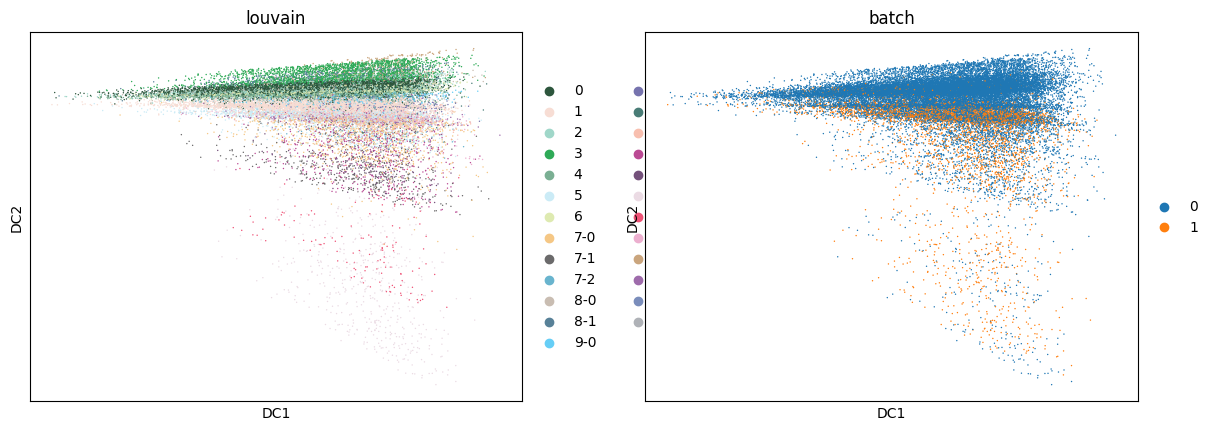

In [19]:
sc.pl.diffmap(adata_diff, color=['louvain','batch'])

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


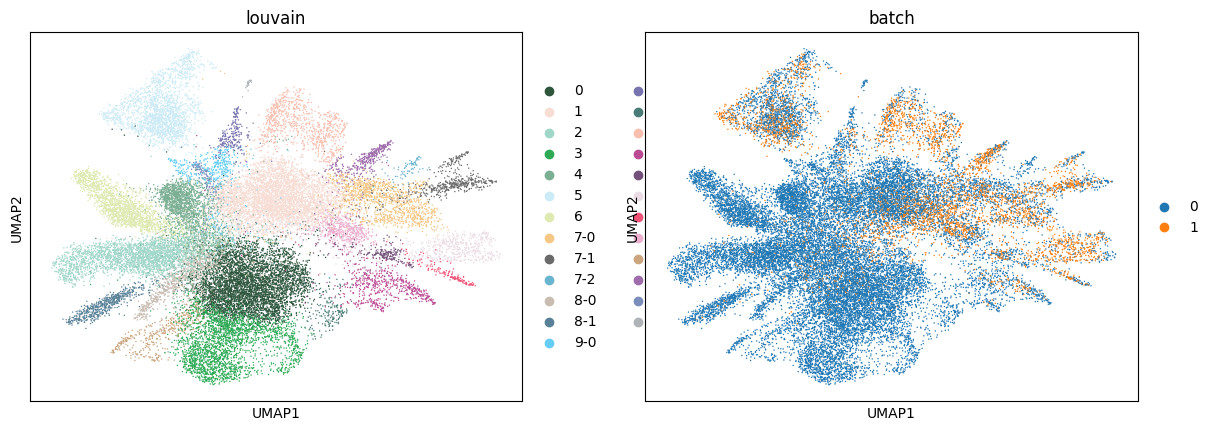

In [26]:
sc.pl.umap(adata_diff, color=['louvain','batch'])

In [27]:
sc.tl.dpt(adata_diff, n_branchings=0, n_dcs=10)

In [63]:
adata_diff.obsp['connectivities']

<28825x28825 sparse matrix of type '<class 'numpy.float64'>'
	with 693196 stored elements in Compressed Sparse Row format>

<Axes: ylabel='Frequency'>

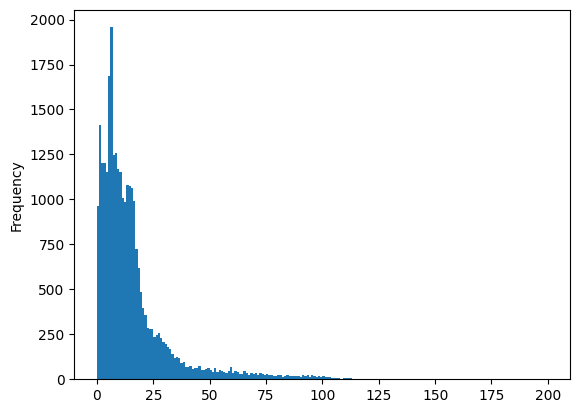

In [30]:
adata_diff.obs['discrete_time'].plot(kind='hist', bins=200)

In [33]:
random_split(adata_diff)

In [29]:
adata_diff.obs['discrete_time'] = adata_diff.obs.dpt_pseudotime.apply(discrete_time)

In [54]:
adata_diff.uns['unique_token_dict'] = token_dict

In [58]:
max(token_dict.values())

3550

In [59]:
len(token_dict.values())

3369

In [55]:
adata_diff.write_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

In [65]:
adata_diff.X.max(axis=0)

array([10.       , 10.       ,  4.163133 , ..., 10.       ,  4.145881 ,
        3.6173196], dtype=float32)

# sub TF

In [ ]:
adata_subTF = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_subsample.h5ad")

# adata_subTF.obs.reset_index(inplace=True)
# adata_subTF.obs.rename({"index":"cellbarcode"},axis=1,inplace=True)

In [ ]:
random_split(adata_subTF)

In [ ]:
adata_subTF.obs['discrete_time'] = adata_subTF.obs.dpt_pseudotime.apply(discrete_time)

In [72]:
adata_subTF

AnnData object with n_obs × n_vars = 671453 × 3517
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'v_pseudotime', 'split', 'discrete_time'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'diffmap_evals', 'draw_graph', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'unique_token_dict'
    obsm: 'NMF', 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

<Axes: ylabel='Frequency'>

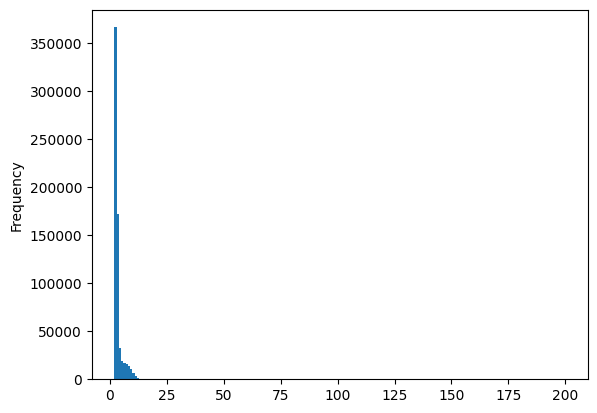

In [71]:
adata_subTF.obs['discrete_time'].plot(kind='hist', bins=200)

In [69]:
adata_subTF.uns['unique_token_dict'] = token_dict

In [77]:
sc.pp.neighbors(adata_subTF, n_neighbors=20, n_pcs=30)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [96]:
np.argpartition(np.ravel(adata_subTF.obsp['connectivities'][6]).todense(), 15)

AttributeError: 'numpy.ndarray' object has no attribute 'todense'

In [79]:
adata_subTF.write_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_subsample.h5ad")

In [9]:
adata_subTF.obsm['NMF'][:10,:]

array([[ 1.99865231e-02,  0.00000000e+00,  1.04033165e-01,
         2.71576460e-02,  4.32203888e-02,  3.77825124e-02,
         5.50229877e-03,  4.85447989e-03,  1.06399313e-02,
         5.24101674e-03,  1.08450411e-02,  0.00000000e+00,
         6.72470213e-03,  0.00000000e+00,  1.07022381e-02,
         0.00000000e+00,  0.00000000e+00,  7.39722389e-03,
         0.00000000e+00,  4.97078270e-03,  0.00000000e+00,
         2.61181617e-03,  2.46834324e-03,  0.00000000e+00,
         9.30641512e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.37201137e-02,  0.00000000e+00,
         3.03785675e-02,  0.00000000e+00,  3.73221411e-02,
         5.65022042e-03,  0.00000000e+00,  1.78796701e-02,
         7.14930323e-03,  2.64598391e-02,  0.00000000e+00,
         0.00000000e+00,  3.70097240e-03,  0.00000000e+00,
         8.24700246e-03,  0.00000000e+00,  1.95610877e-02,
         5.23657224e-02,  0.00000000e+00,  0.00000000e+00,
         2.41011259e-02,  0.00000000e+00,  0.00000000e+0